# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject


## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [2]:
df = pd.read_csv('../data/dayofweek.csv')

df.head()

X = df.drop(columns='dayofweek')
y = df['dayofweek']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2)

In [4]:
y_train.value_counts()

3    313
6    287
1    222
5    216
2    125
0    105
4     80
Name: dayofweek, dtype: int64

In [5]:
y_test.value_counts()

3    83
6    69
5    55
1    52
0    31
4    24
2    24
Name: dayofweek, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2, stratify=y)

In [7]:
y_train.value_counts()

3    316
6    285
1    219
5    217
2    119
0    109
4     83
Name: dayofweek, dtype: int64

In [8]:
y_test.value_counts()

3    80
6    71
1    55
5    54
2    30
0    27
4    21
Name: dayofweek, dtype: int64

## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [9]:
lr = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')

lr = lr.fit(X_train, y_train)

print(f'Точность модели логистической регрессии: {lr.score(X_test, y_test)}')

Точность модели логистической регрессии: 0.6153846153846154


### b. SVM

In [10]:
svc = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))

svc = svc.fit(X_train, y_train)

print(f'Точность модели метода опорных векторов: {svc.score(X_test, y_test)}')

Точность модели метода опорных векторов: 0.6183431952662722


### c. Decision tree

In [11]:
dtc = DecisionTreeClassifier(max_depth=4, random_state=21)

dtc = dtc.fit(X_train, y_train)

print(f'Точность модели дерева решения: {dtc.score(X_test, y_test)}')

Точность модели дерева решения: 0.5295857988165681


### d. Random forest

In [12]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)

rfc = rfc.fit(X_train, y_train)

print(f'Точность модели случайного леса: {rfc.score(X_test, y_test)}')

Точность модели случайного леса: 0.9289940828402367


Вопрос:
Показали ли все модели схожие значения метрики? Какая из них имеет наибольшую разницу между текущим и предыдущим упражнениями?

Ответ: Показатели некоторых моделей довольно значительно изменились Случайный лес имеет наибольшую разницу.

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [13]:
scores_lg = cross_val_score(lr, X_train, y_train, cv=10)
print(f"Средняя точность: {scores_lg.mean()}\nСреднее отклонение: {scores_lg.std()}")

Средняя точность: 0.5815975677169707
Среднее отклонение: 0.025322132907253592


### b. SVM

In [14]:
scores_svc = cross_val_score(svc, X_train, y_train, cv=10)

print(f"Средняя точность: {scores_svc.mean()},\nСреднее отклонение: {scores_svc.std()}")

Средняя точность: 0.5705085682697624,
Среднее отклонение: 0.037010421284044116


### c. Decision tree

In [15]:
scores_dtc = cross_val_score(dtc, X_train, y_train, cv=10)

print(f"Средняя точность: {scores_dtc.mean()},\nСреднее отклонение: {scores_dtc.std()}")

Средняя точность: 0.5088944168048645,
Среднее отклонение: 0.031903139495514356


### d. Random forest

In [16]:
scores_rfc = cross_val_score(rfc, X_train, y_train, cv=10)

print(f"Средняя точность: {scores_rfc.mean()},\nСреднее отклонение: {scores_rfc.std()}")

Средняя точность: 0.9176561636263129,
Среднее отклонение: 0.02159583796321821


## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

In [17]:
param_grid = {
    "n_estimators": [100, 250, 300],
    "max_features": ['sqrt', 'log2'],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [1, 2, 3]
    }

rfc = RandomForestClassifier(random_state=21)

grid = GridSearchCV(
    rfc,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy'
    )

model_grid = grid.fit(X_train, y_train)

print(f'Лучшие гиперпараметры: {model_grid.best_params_}\nИх точность: {model_grid.score(X_test, y_test)}')

Лучшие гиперпараметры: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
Их точность: 0.9408284023668639


In [18]:
rfc = RandomForestClassifier(n_estimators=250, max_depth=30, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=21)

In [19]:
rfc = rfc.fit(X_train, y_train)

print(f'Точность итоговой модели: {rfc.score(X_test, y_test)}')

Точность итоговой модели: 0.9408284023668639


<BarContainer object of 10 artists>

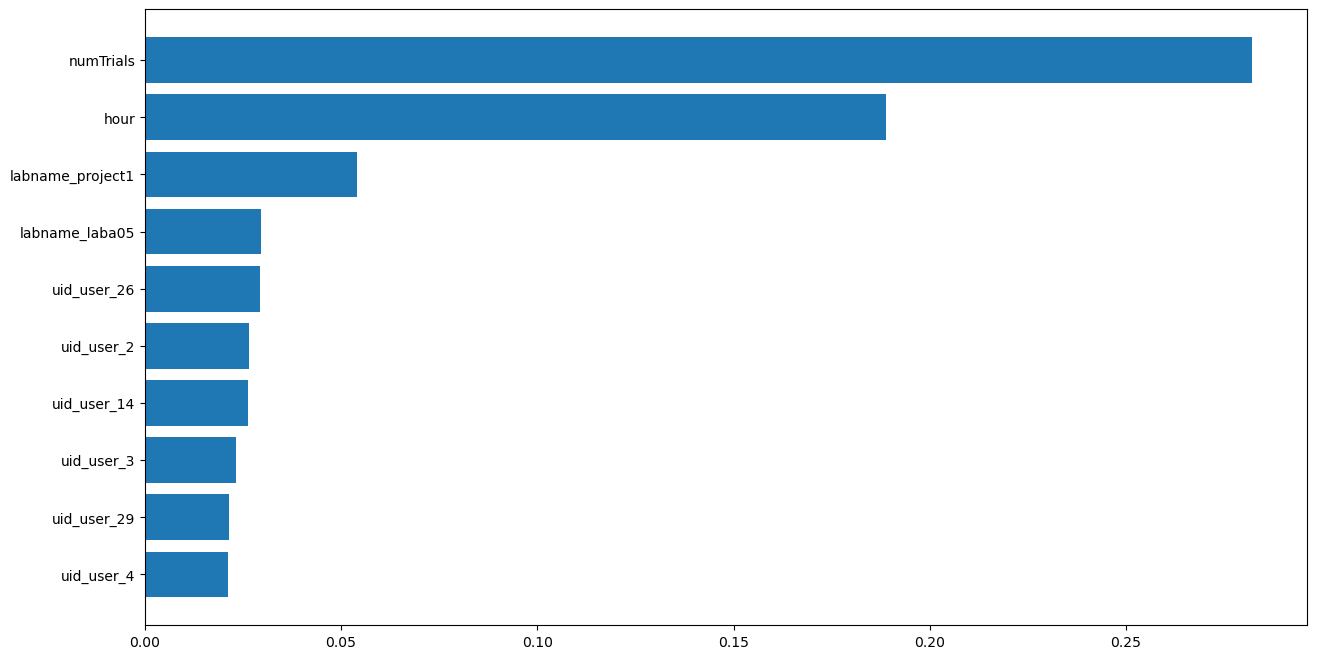

In [20]:
importance = np.abs(rfc.feature_importances_)
sorted_indices = np.argsort(importance)[-10:]
sorted_importance = importance[sorted_indices]
sorted_features = X.columns[sorted_indices]

plt.figure(figsize=(15, 8))
plt.barh(sorted_features, sorted_importance)

In [21]:
joblib.dump(rfc, '../data/model.pkl')

['../data/model.pkl']

In [22]:
rfc2 = joblib.load('../data/model.pkl')

In [23]:
y_pred = rfc2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy загруженной модели составляет: {accuracy}')

Accuracy загруженной модели составляет: 0.9408284023668639
